In [1]:
# import required packages
import obspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# import phase picks from CSV file
#phasepicks = pd.read_csv('../data/ax.hinv.pha.shots_erup', comment='#')


print(phasepicks)

           OOAXAS2     1.420  -1.000   P EH 
0          OOAXAS2     1.930  -1.000   S EH 
1          OOAXEC3     1.290  -0.500   P EH 
2          OOAXEC3     2.460  -0.200   S EH 
3          OOAXEC2     0.680   0.500   P HH 
4          OOAXEC2     3.480  -1.000   S HH 
...                                      ...
2278015  OOAXID1       0.710   1.000   S EH 
2278016  OOAXEC3       0.460   1.000   P EH 
2278017  OOAXEC3       0.920   1.000   S EH 
2278018  OOAXAS1       0.560   1.000   P EH 
2278019  OOAXAS1       1.280   1.000   S EH 

[2278020 rows x 1 columns]


In [3]:
# name column

phasepicks.columns = ['event']
# Split the 'event' column by whitespace
split_cols = phasepicks['event'].str.split(expand=True)

# Assign appropriate column names based on the number of columns
split_cols.columns = ['station', 'time', 'mag', 'wave', 'pick'][:split_cols.shape[1]]

# Concatenate the split columns with the original dataframe (if needed)
phasepicks = split_cols

In [ ]:
# check phase pick dataframe
display(phasepicks)

,station,time,mag,wave,pick
0,OOAXAS2,1.930,-1.000,S,EH
1,OOAXEC3,1.290,-0.500,P,EH
2,OOAXEC3,2.460,-0.200,S,EH
3,OOAXEC2,0.680,0.500,P,HH
4,OOAXEC2,3.480,-1.000,S,HH
...,...,...,...,...,...
2278015,OOAXID1,0.710,1.000,S,EH
2278016,OOAXEC3,0.460,1.000,P,EH
2278017,OOAXEC3,0.920,1.000,S,EH
2278018,OOAXAS1,0.560,1.000,P,EH


In [28]:
# Get unique station names from phasepicks dataframe
unique_stations = phasepicks['station'].unique()

# Sort the station names for better readability
unique_stations.sort()

# Print the list of unique station names
print(f"Number of unique stations: {len(unique_stations)}")
print("\nList of unique stations:")
print(unique_stations)

Number of unique stations: 7

List of unique stations:
['OOAXAS1' 'OOAXAS2' 'OOAXCC1' 'OOAXEC1' 'OOAXEC2' 'OOAXEC3' 'OOAXID1']


In [29]:
# Save the phasepicks dataframe to a CSV file
phasepicks.to_csv('../data/processed_phasepicks.csv', index=False)

# Print confirmation message
print(f"Phasepicks dataframe successfully saved to '../data/processed_phasepicks.csv'")

Phasepicks dataframe successfully saved to '../data/processed_phasepicks.csv'


In [5]:
catalog = pd.read_csv('../data/Axial.MLDD.v202112.2')
print(catalog)

       2014 11  4 20 42 12.532    45.94124   -130.01128    0.375   0.012   0.010  62   0.006  0.1    1000001
0       2014 11  4 20 46  1.620    45.93439   -130.020...                                                   
1       2014 11  4 22 12 40.197    45.92662   -130.015...                                                   
2       2014 11  4 22 41  7.813    45.92568   -129.980...                                                   
3       2014 11  5  0 43  9.964    45.94480   -129.994...                                                   
4       2014 11  5  1  3 48.101    45.93533   -129.984...                                                   
...                                                   ...                                                   
144323  2021 12 27 17  3 40.440    45.94228   -130.013...                                                   
144324  2021 12 27 19 51 32.350    45.93447   -130.019...                                                   
144325  2021 12 28 

In [6]:
catalog.columns = ['event']
# Split the 'event' column by whitespace
split_cols = catalog['event'].str.split(expand=True)

# Assign appropriate column names based on the number of columns
split_cols.columns = ['year', 'month', 'day', 'hour', 'minute', 'second', 'lat', 'lon', 'dep', 'eh1', 'eh2', 'az', 'ez', 'mag', 'id'][:split_cols.shape[1]]

# Concatenate the split columns with the original dataframe (if needed)
catalog = split_cols

In [7]:
display(catalog)

,year,month,day,hour,minute,second,lat,lon,dep,eh1,eh2,az,ez,mag,id
0,2014,11,4,20,46,1.620,45.93439,-130.02092,1.148,0.432,0.023,168,0.030,1.5,1000002
1,2014,11,4,22,12,40.197,45.92662,-130.01597,0.904,0.089,0.027,114,0.039,0.2,1000010
2,2014,11,4,22,41,7.813,45.92568,-129.98059,0.821,0.016,0.000,146,0.003,0.4,1000012
3,2014,11,5,0,43,9.964,45.94480,-129.99482,1.140,0.222,0.030,87,0.698,-0.0,1000025
4,2014,11,5,1,3,48.101,45.93533,-129.98498,0.559,-1.000,-1.000,-1,-1.000,-0.1,1000030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144323,2021,12,27,17,3,40.440,45.94228,-130.01324,0.463,0.015,0.007,86,0.005,0.3,1501597
144324,2021,12,27,19,51,32.350,45.93447,-130.01936,1.230,0.020,0.010,42,0.008,0.7,1501600
144325,2021,12,28,2,33,58.284,45.95371,-129.99781,0.436,0.137,0.008,9,0.014,0.3,1501602
144326,2021,12,29,0,9,14.414,45.94125,-130.02061,1.005,0.021,0.007,74,0.009,1.2,1501617


In [30]:
# Save the catalog dataframe to a CSV file
catalog.to_csv('../data/processed_catalog.csv', index=False)

# Print confirmation message
print(f"Catalog dataframe successfully saved to '../data/processed_catalog.csv'")

Catalog dataframe successfully saved to '../data/processed_catalog.csv'


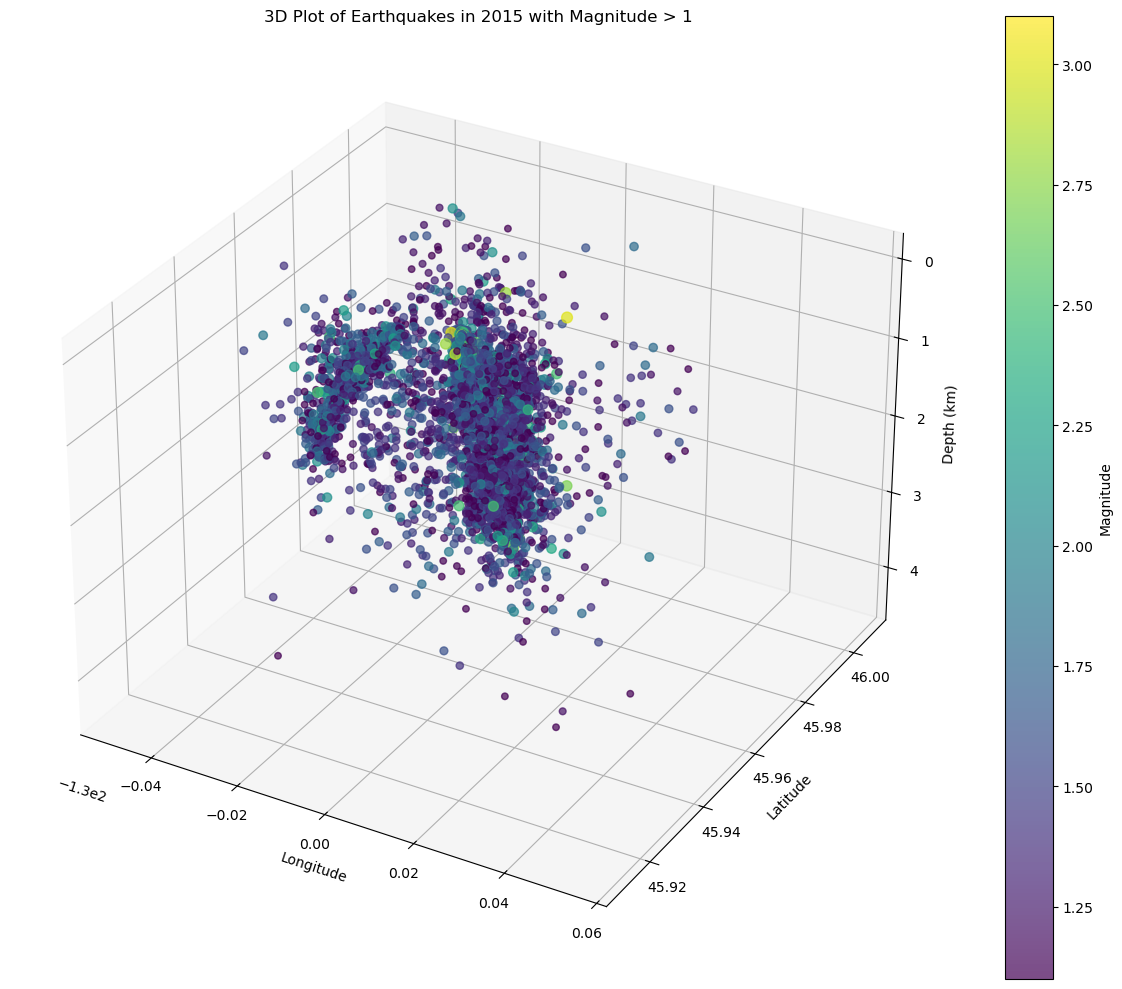

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Convert necessary columns to numeric
catalog['lat'] = pd.to_numeric(catalog['lat'])
catalog['lon'] = pd.to_numeric(catalog['lon'])
catalog['dep'] = pd.to_numeric(catalog['dep'])
catalog['mag'] = pd.to_numeric(catalog['mag'])
catalog['year'] = pd.to_numeric(catalog['year'])

# Filter data for events from 2015 with magnitude > 1
filtered_data = catalog[(catalog['year'] == 2015) & (catalog['mag'] > 1)]

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot with size based on magnitude
scatter = ax.scatter(
    filtered_data['lon'], 
    filtered_data['lat'], 
    filtered_data['dep'],
    c=filtered_data['mag'],
    s=filtered_data['mag']*20,  # Scale the size by magnitude
    cmap='viridis',
    alpha=0.7
)

# Set axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Depth (km)')
ax.invert_zaxis()  # Invert z-axis so depth increases downward

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')

# Add title
plt.title('3D Plot of Earthquakes in 2015 with Magnitude > 1')

plt.tight_layout()
# Save Save figure figure before before showing showing it it
plt.savefig('../3d_plot_2015_mag_gt_1.png', dpi=300)
plt.show()

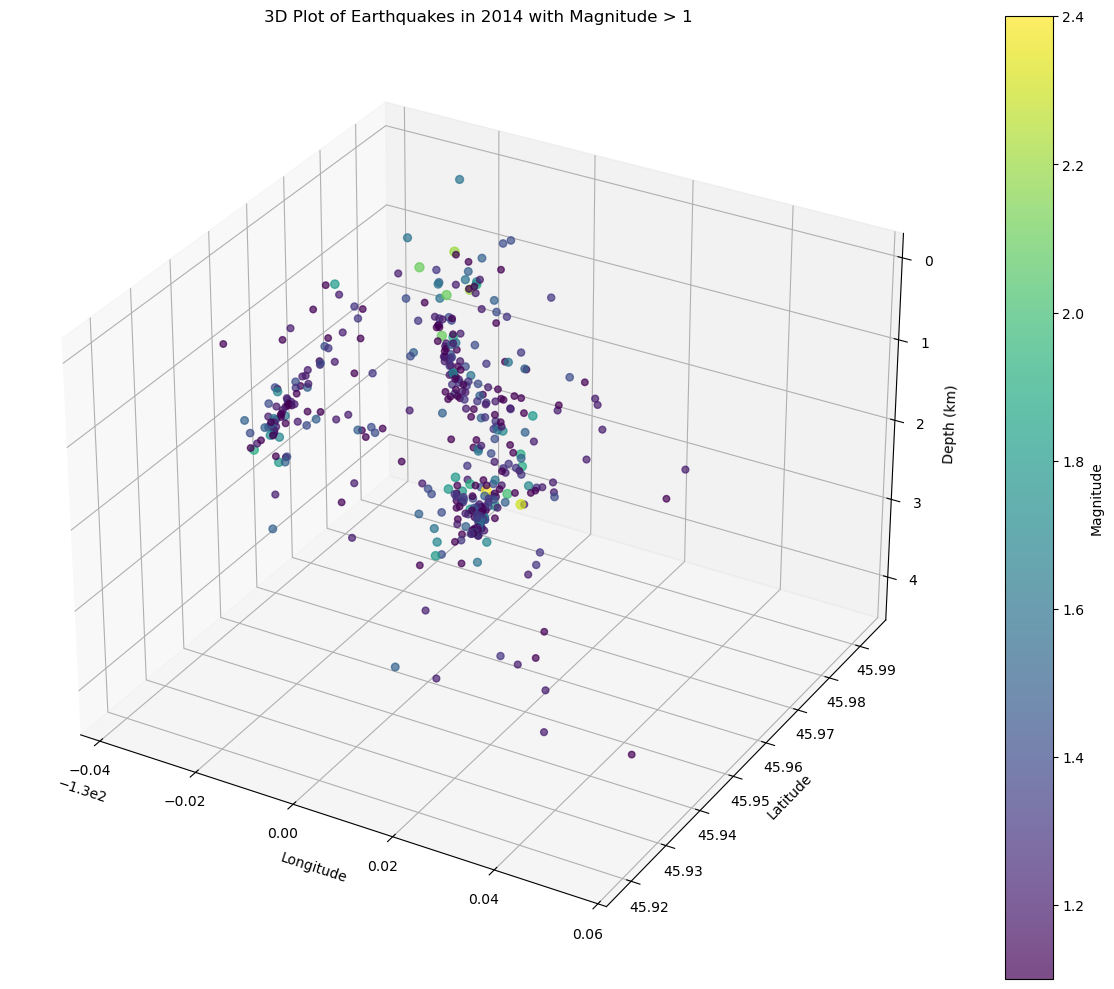

In [15]:
from mpl_toolkits.mplot3d import Axes3D

# Convert necessary columns to numeric
catalog['lat'] = pd.to_numeric(catalog['lat'])
catalog['lon'] = pd.to_numeric(catalog['lon'])
catalog['dep'] = pd.to_numeric(catalog['dep'])
catalog['mag'] = pd.to_numeric(catalog['mag'])
catalog['year'] = pd.to_numeric(catalog['year'])

# Filter data for events from 2014 with magnitude > 1
filtered_data = catalog[(catalog['year'] == 2014) & (catalog['mag'] > 1)]

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot with size based on magnitude
scatter = ax.scatter(
    filtered_data['lon'], 
    filtered_data['lat'], 
    filtered_data['dep'],
    c=filtered_data['mag'],
    s=filtered_data['mag']*20,  # Scale the size by magnitude
    cmap='viridis',
    alpha=0.7
)

# Set axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Depth (km)')
ax.invert_zaxis()  # Invert z-axis so depth increases downward

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')

# Add title
plt.title('3D Plot of Earthquakes in 2014 with Magnitude > 1')

plt.tight_layout()
# Save Save figure figure before before showing showing it it
plt.savefig('../3d_plot_2014_mag_gt_1.png', dpi=300)
plt.show()

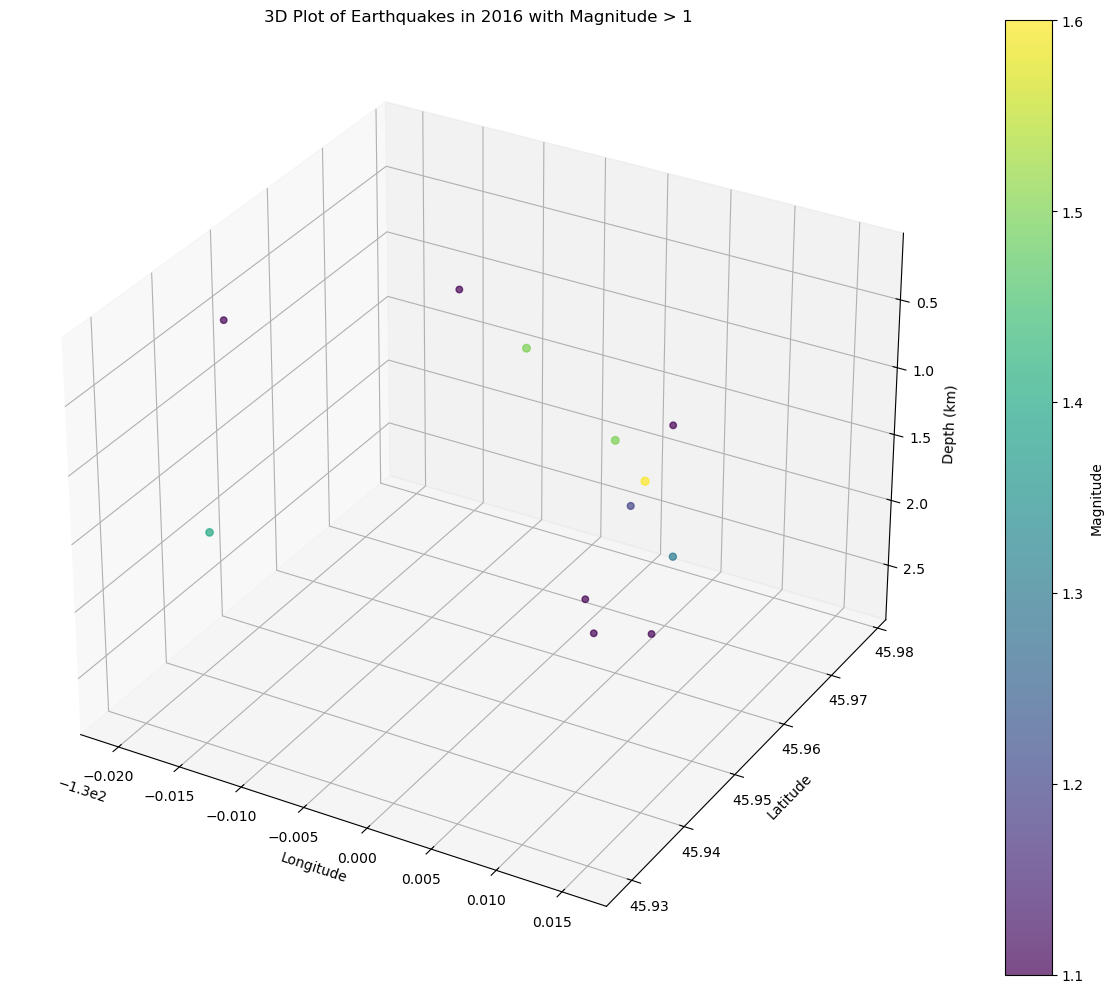

In [16]:
from mpl_toolkits.mplot3d import Axes3D

# Convert necessary columns to numeric
catalog['lat'] = pd.to_numeric(catalog['lat'])
catalog['lon'] = pd.to_numeric(catalog['lon'])
catalog['dep'] = pd.to_numeric(catalog['dep'])
catalog['mag'] = pd.to_numeric(catalog['mag'])
catalog['year'] = pd.to_numeric(catalog['year'])

# Filter data for events from 2016 with magnitude > 1
filtered_data = catalog[(catalog['year'] == 2016) & (catalog['mag'] > 1)]

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot with size based on magnitude
scatter = ax.scatter(
    filtered_data['lon'], 
    filtered_data['lat'], 
    filtered_data['dep'],
    c=filtered_data['mag'],
    s=filtered_data['mag']*20,  # Scale the size by magnitude
    cmap='viridis',
    alpha=0.7
)

# Set axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Depth (km)')
ax.invert_zaxis()  # Invert z-axis so depth increases downward

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')

# Add title
plt.title('3D Plot of Earthquakes in 2016 with Magnitude > 1')

plt.tight_layout()
# Save Save figure figure before before showing showing it it
plt.savefig('../3d_plot_2016_mag_gt_1.png', dpi=300)
plt.show()

In [ ]:
# Calculate possible angle of incidence approximations

# Method 1: If eh1/eh2 represent some form of ray path geometry
# This is speculative - you'd need to verify with your data documentation
catalog['ellipse_ratio'] = catalog['eh1'] / catalog['eh2']
catalog['ellipse_angle'] = np.arctan2(catalog['eh2'], catalog['eh1']) * 180/np.pi

# Method 2: If you have station locations, calculate epicentral distance and use depth
# Assuming a reference station location (you'd need actual station coordinates)
# This is just an example - replace with actual station coordinates
station_lat = 45.93  # Example latitude for Axial Seamount area
station_lon = -130.01  # Example longitude

# Calculate epicentral distance (rough approximation)
catalog['delta_lat'] = catalog['lat'] - station_lat
catalog['delta_lon'] = catalog['lon'] - station_lon
catalog['epicentral_dist_deg'] = np.sqrt(catalog['delta_lat']**2 + catalog['delta_lon']**2)

# Convert to km (rough approximation: 1 degree ≈ 111 km)
catalog['epicentral_dist_km'] = catalog['epicentral_dist_deg'] * 111

# Calculate angle of incidence from vertical (simple geometric approach)
# angle_of_incidence = arctan(epicentral_distance / depth)
catalog['angle_of_incidence'] = np.arctan2(catalog['epicentral_dist_km'], catalog['dep']) * 180/np.pi

# Display results
print("Calculated parameters:")
print(catalog[['eh1', 'eh2', 'az', 'ellipse_ratio', 'angle_of_incidence']].describe())

# Plot the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: eh1 vs eh2
ax1.scatter(catalog['eh1'], catalog['eh2'], alpha=0.6, s=10)
ax1.set_xlabel('eh1')
ax1.set_ylabel('eh2')
ax1.set_title('Error Ellipse: eh1 vs eh2')
ax1.grid(True, alpha=0.3)

# Plot 2: Azimuth distribution
ax2.hist(catalog['az'], bins=50, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Azimuth (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Azimuth Distribution')
ax2.grid(True, alpha=0.3)

# Plot 3: Angle of incidence vs depth
ax3.scatter(catalog['dep'], catalog['angle_of_incidence'], alpha=0.6, s=10, c=catalog['mag'], cmap='viridis')
ax3.set_xlabel('Depth (km)')
ax3.set_ylabel('Angle of Incidence (degrees)')
ax3.set_title('Angle of Incidence vs Depth')
ax3.grid(True, alpha=0.3)

# Plot 4: Angle of incidence distribution
ax4.hist(catalog['angle_of_incidence'], bins=50, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Angle of Incidence (degrees)')
ax4.set_ylabel('Frequency')
ax4.set_title('Angle of Incidence Distribution')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../angle_of_incidence_analysis.png', dpi=300)
plt.show()

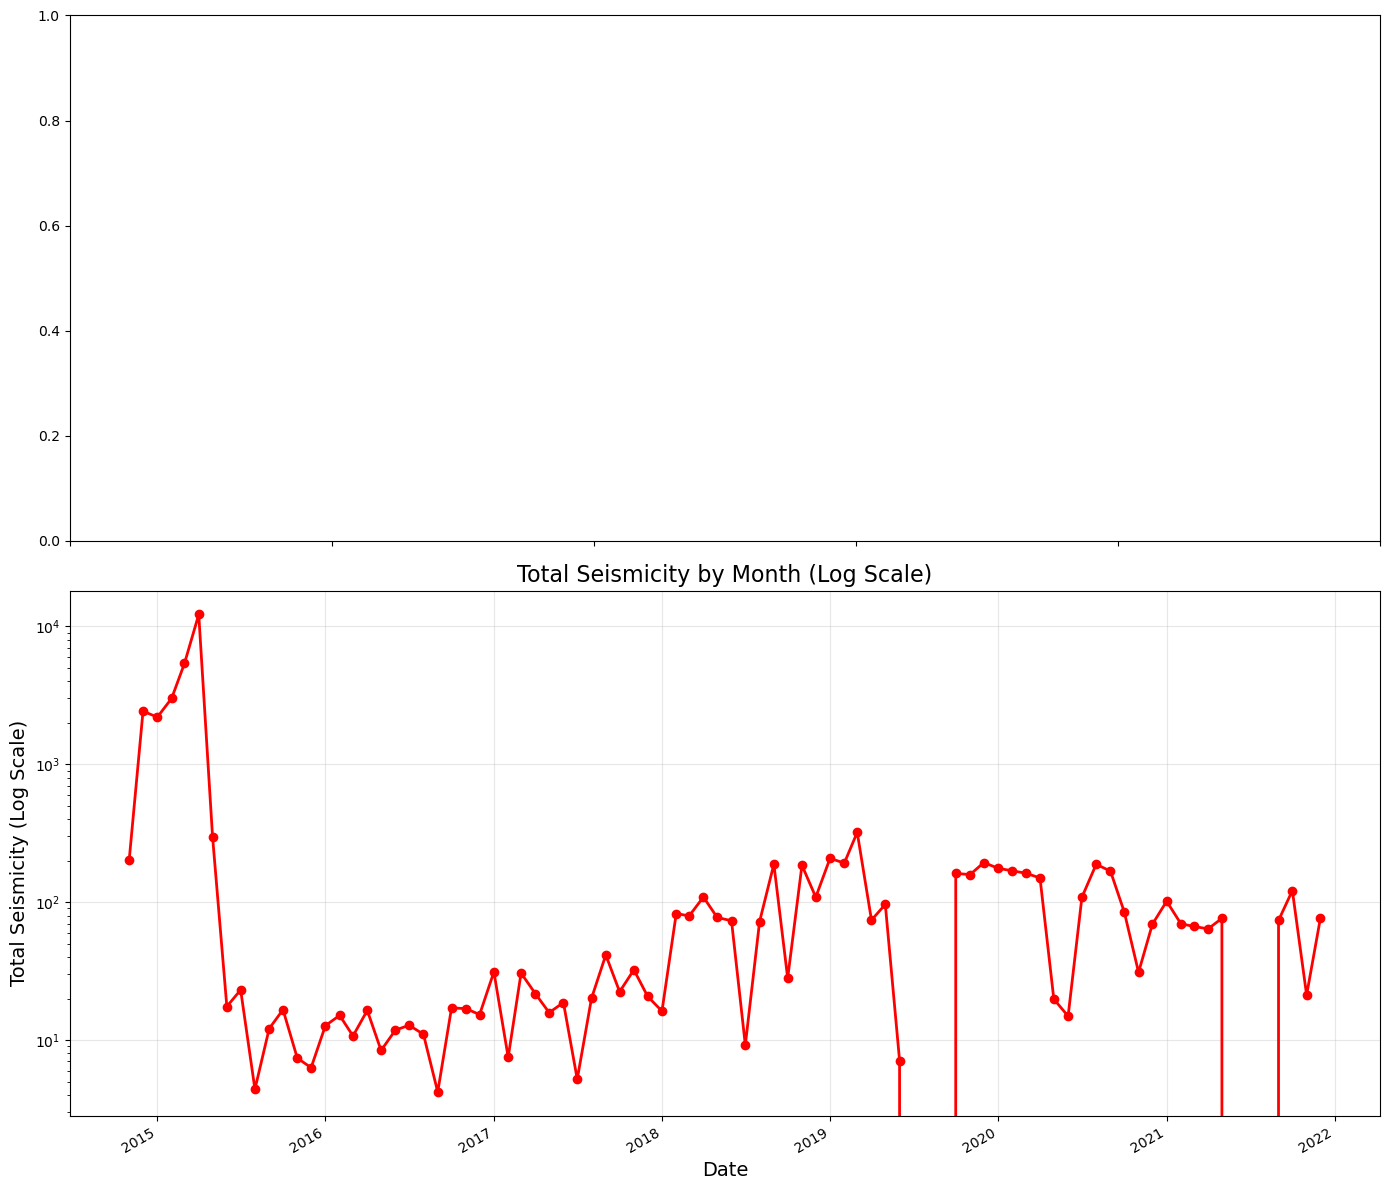

In [25]:
# Group by year and month, and sum the magnitudes
monthly_mag_sum = catalog.groupby('date')['mag'].sum().reset_index()

# Create two subplots - one normal scale, one logarithmic scale
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))



# Plot 2: Logarithmic scale for magnitudes
ax2.plot(monthly_mag_sum['date'], monthly_mag_sum['mag'], marker='o', linestyle='-', linewidth=2, color='red')
ax2.set_yscale('log')
ax2.set_title('Total Seismicity by Month (Log Scale)', fontsize=16)
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylabel('Total Seismicity (Log Scale)', fontsize=14)
ax2.grid(True, alpha=0.3)


# Format x-axis with year-month for both plots
for ax in [ax1, ax2]:
    plt.sca(ax)
    plt.gcf().autofmt_xdate()

plt.tight_layout()

# Save figure before showing it
plt.savefig('../monthly_magnitude_sum_with_log.png', dpi=300)
plt.show()

In [ ]:
# Explore the eh1, eh2, and az columns to understand their values
print("Exploring error ellipse parameters:")
print(f"eh1 range: {catalog['eh1'].min()} to {catalog['eh1'].max()}")
print(f"eh2 range: {catalog['eh2'].min()} to {catalog['eh2'].max()}")
print(f"az range: {catalog['az'].min()} to {catalog['az'].max()}")

# Convert to numeric if not already
catalog['eh1'] = pd.to_numeric(catalog['eh1'], errors='coerce')
catalog['eh2'] = pd.to_numeric(catalog['eh2'], errors='coerce')
catalog['az'] = pd.to_numeric(catalog['az'], errors='coerce')

# Check for any non-numeric values
print(f"\nNaN values - eh1: {catalog['eh1'].isna().sum()}, eh2: {catalog['eh2'].isna().sum()}, az: {catalog['az'].isna().sum()}")

# Show first few rows of these columns
print("\nFirst 10 rows of error ellipse data:")
print(catalog[['eh1', 'eh2', 'az', 'dep', 'lat', 'lon']].head(10))

# Analyze the az distribution to understand what it represents
print(f"\nAnalyzing 'az' variable:")
print(f"Mean: {catalog['az'].mean():.2f}°")
print(f"Std: {catalog['az'].std():.2f}°")
print(f"Values > 180°: {(catalog['az'] > 180).sum()} out of {len(catalog)}")

# Plot histogram of az values
plt.figure(figsize=(10, 6))
plt.hist(catalog['az'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('az (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of az values (Error Ellipse Azimuth)')
plt.grid(True, alpha=0.3)
plt.axvline(x=180, color='red', linestyle='--', label='180° line')
plt.legend()
plt.show()

print("\nInterpretation:")
print("If 'az' represents error ellipse azimuth:")
print("- Values should range 0-180° (or 0-360°)")
print("- Describes orientation of location uncertainty ellipse")
print("- NOT the same as back-azimuth from station to earthquake")

In [ ]:
# Calculate actual back-azimuth from station to earthquake
# You'll need to replace these with actual station coordinates

# Example Axial Seamount station coordinates (replace with real ones)
stations = {
    'AXAS1': {'lat': 45.9298, 'lon': -130.0067},
    'AXAS2': {'lat': 45.9242, 'lon': -130.0108}, 
    'AXCC1': {'lat': 45.9540, 'lon': -129.9775},
    'AXEC1': {'lat': 45.9390, 'lon': -129.9730}
}

def calculate_back_azimuth(eq_lat, eq_lon, sta_lat, sta_lon):
    """Calculate back-azimuth from station to earthquake"""
    # Convert to radians
    eq_lat_rad = np.radians(eq_lat)
    eq_lon_rad = np.radians(eq_lon) 
    sta_lat_rad = np.radians(sta_lat)
    sta_lon_rad = np.radians(sta_lon)
    
    # Calculate difference
    dlon = eq_lon_rad - sta_lon_rad
    
    # Calculate back-azimuth
    y = np.sin(dlon) * np.cos(eq_lat_rad)
    x = (np.cos(sta_lat_rad) * np.sin(eq_lat_rad) - 
         np.sin(sta_lat_rad) * np.cos(eq_lat_rad) * np.cos(dlon))
    
    back_az = np.degrees(np.arctan2(y, x))
    
    # Normalize to 0-360°
    back_az = (back_az + 360) % 360
    
    return back_az

# Calculate back-azimuth for AXAS1 station as example
station_name = 'AXAS1'
if station_name in stations:
    sta_lat = stations[station_name]['lat']
    sta_lon = stations[station_name]['lon']
    
    catalog['back_azimuth_AXAS1'] = calculate_back_azimuth(
        catalog['lat'], catalog['lon'], sta_lat, sta_lon
    )
    
    # Compare 'az' with calculated back-azimuth
    print(f"\nComparison: 'az' vs Back-azimuth to {station_name}")
    print(f"'az' range: {catalog['az'].min():.1f}° to {catalog['az'].max():.1f}°")
    print(f"Back-azimuth range: {catalog['back_azimuth_AXAS1'].min():.1f}° to {catalog['back_azimuth_AXAS1'].max():.1f}°")
    
    # Plot comparison
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: az distribution
    ax1.hist(catalog['az'], bins=50, alpha=0.7, color='blue', label='az (error ellipse)')
    ax1.set_xlabel('Angle (degrees)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of "az" values')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: back-azimuth distribution  
    ax2.hist(catalog['back_azimuth_AXAS1'], bins=50, alpha=0.7, color='red', label='back-azimuth')
    ax2.set_xlabel('Angle (degrees)')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Back-azimuth to {station_name}')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: scatter plot comparison
    ax3.scatter(catalog['az'], catalog['back_azimuth_AXAS1'], alpha=0.6, s=10)
    ax3.set_xlabel('az (error ellipse azimuth)')
    ax3.set_ylabel('Back-azimuth (degrees)')
    ax3.set_title('az vs Back-azimuth')
    ax3.grid(True, alpha=0.3)
    
    # Add diagonal line if they were the same
    min_val = min(catalog['az'].min(), catalog['back_azimuth_AXAS1'].min())
    max_val = max(catalog['az'].max(), catalog['back_azimuth_AXAS1'].max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='1:1 line')
    ax3.legend()
    
    plt.tight_layout()
    plt.savefig('../az_vs_back_azimuth_comparison.png', dpi=300)
    plt.show()
    
    print("\nConclusion:")
    print("- 'az' is the ERROR ELLIPSE azimuth (location uncertainty orientation)")
    print("- Back-azimuth is the direction FROM station TO earthquake")
    print("- These are completely different quantities!")
else:
    print(f"Station {station_name} coordinates not found")

# Shear-Wave Splitting Analysis Overview

**What you NEED for basic splitting analysis:**
1. **3-component seismograms** (Z, N, E components)
2. **S-wave arrival times** 
3. **Time window** around S-wave (e.g., -2 to +8 seconds)

**What back-azimuth and incidence angle are used for:**
1. **Coordinate rotation** (N,E → Radial,Transverse)
2. **Quality control** (filter steep rays, ensure good coverage)
3. **Interpretation** (compare fast direction to geological features)

**You can start splitting analysis with just the 3-component data!**

In [ ]:
# Basic Shear-Wave Splitting Workflow (conceptual example)

def basic_splitting_workflow():
    """
    Conceptual workflow for shear-wave splitting analysis
    This shows what you actually need vs what's helpful
    """
    
    print("REQUIRED for splitting analysis:")
    print("1. 3-component seismograms (Z, N, E)")
    print("2. S-wave arrival time")
    print("3. Time window around S-wave")
    print()
    
    print("HELPFUL but not strictly required:")
    print("1. Back-azimuth (for rotation to radial/transverse)")
    print("2. Incidence angle (for quality control)")
    print("3. Earthquake magnitude (for SNR filtering)")
    print()
    
    print("Basic splitting analysis steps:")
    print("1. Load 3-component waveforms")
    print("2. Pick S-wave arrival")
    print("3. Extract time window around S-wave")
    print("4. Rotate to radial-transverse coordinates (needs back-azimuth)")
    print("5. Apply splitting analysis algorithm:")
    print("   - Silver & Chan (1991) method")
    print("   - Minimum energy method") 
    print("   - Rotation-correlation method")
    print("6. Measure fast direction (φ) and delay time (δt)")
    print()
    
    print("Why rotation matters:")
    print("- S-waves on radial component should be linearly polarized")
    print("- Splitting creates energy on transverse component")
    print("- Without rotation, splitting signal can be contaminated")

# Call the function to display the workflow
basic_splitting_workflow()

# Example of coordinate rotation (you need back-azimuth for this)
def rotate_to_radial_transverse(north, east, back_azimuth_deg):
    """
    Rotate horizontal components to radial-transverse system
    """
    baz_rad = np.radians(back_azimuth_deg)
    
    # Rotation matrix
    radial = north * np.cos(baz_rad) + east * np.sin(baz_rad)
    transverse = -north * np.sin(baz_rad) + east * np.cos(baz_rad)
    
    return radial, transverse

print("\nExample: If you have N, E components and back-azimuth,")
print("you can rotate to radial-transverse for better splitting analysis.")
print("But you can also do splitting analysis directly on N, E components")